# __2- Model Training__ 

Install torch library

 <span style="color: red;"> RUN IT ONCE IF YOU FACED ERROR IN CELL 3</span>

In [ ]:
!pip install torch torchvision

  Using cached torch-2.10.0-cp311-cp311-win_amd64.whl.metadata (31 kB)
  Using cached torchvision-0.25.0-cp311-cp311-win_amd64.whl.metadata (5.4 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached torch-2.10.0-cp311-cp311-win_amd64.whl (113.7 MB)
Using cached torchvision-0.25.0-cp311-cp311-win_amd64.whl (4.0 MB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\rahaf\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import torch
print(torch.__version__)


2.10.0+cpu


## 2.1 Normlization

In [ ]:
"""
-----------------------------------------------------------------------------
This section defines a pipeline (`transforms.Compose`) to digitally prepare the 
raw images before the model sees them. First, it applies "Data Augmentation"—such 
as randomly rotating the image, flipping it horizontally. 
This artificially increases the variety of our data, forcing the model to learn the 
actual shape of the hand rather than memorizing a specific photo's background or lighting. 

Outcome: The raw, unpredictable images are converted into standardized, mathematically 
scaled matrices (Tensors). This ensures the neural network can process the images efficiently 
and makes the final model highly robust against variations in real-world lighting.
-----------------------------------------------------------------------------
"""

import torch # pytorch main libirary
from torchvision import transforms # tp process images
from torch.utils.data import Dataset, DataLoader # Dataset to build a class for data , Dataloader to send data to the model as batches
from PIL import Image # to open images
import pandas as pd # to use train_df/val_df/test_df

transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


 Normliazation Equation = $$ \frac{x - mean}{std} = x_{normalized} $$

## 2.2 Dataset Class

 This class is needed to specify how to read images and how to return the image and its label.

In [ ]:
class GestureDataset(Dataset):
    def __init__(self, dataframe, transform=None): # to store data & transformers
        """
        Initialization: This method sets up the dataset by storing the rules for image 
        transformation and the CSV data. Crucially, it creates a `label_map` dictionary. 
        Because neural networks cannot read this so dictionary translates the 
        text label into numbers as 0 and 1.
        
        Outcome: The dataset object knows exactly how to translate human-readable 
        categories into machine-readable binary numbers.
        """
        self.dataframe = dataframe
        self.transform = transform

        self.label_map = { # Palm -> 0 , Fist -> 1
            "Palm": 0,
            "Fist": 1
        }

    def __len__(self): # Dataloader will use it to know the size of data
        return len(self.dataframe)
    """
        Length: Counts and returns the total number of images listed in the dataframe.
        
        Outcome: The system knows the exact size of the dataset, which is necessary 
        for the AI to know when it has completed one full cycle (epoch) of training.
        """

    def __getitem__(self, idx):   
        """
        Data Retrieval : When the model requests an image, this method 
        uses the index number to locate the image path in the CSV. It opens the image, 
        converts it to standard RGB color, applies the defined transformations, and 
        fetches the corresponding binary label.
        
        Outcome: For any given request, it outputs a fully processed image tensor paired 
        with its correct mathematical label (0 or 1), ready for the neural network.
        """                        # most importent function works like follows:
    
        img_path = self.dataframe.iloc[idx]["image_path"] # 1- take image path
        label = self.dataframe.iloc[idx]["label"]         # 2- open image

        image = Image.open(img_path).convert("RGB")       # 3- convert it to RGB

        if self.transform:                                # 4- apply transform
            image = self.transform(image)

        label = self.label_map[label]                     # 5- convert label to image

        return image, label                               # 6- return (image,label)


## 2.3 Creat Dataset for Each Split 

In [ ]:
"""
-----------------------------------------------------------------------------
The code reads the training, validation, and testing CSV files and wraps them in 
DataLoader objects. The DataLoader acts as an automated conveyor belt. Instead of 
sending all images to the processor at once, 
it groups them into batches of 32. 

Outcome: The entire dataset is partitioned into automated, memory-efficient batches. 
For training, the data is shuffled so the model learns the features, not the sequence.
-----------------------------------------------------------------------------
"""
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

train_dataset = GestureDataset(train_df, transform=transform)
val_dataset = GestureDataset(val_df, transform=transform)
test_dataset = GestureDataset(test_df, transform=transform)

## 2.3 Creat DataLoder

In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # every time pass 32 images
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## 2.4 Model Prepatation

In [ ]:
"""
-----------------------------------------------------------------------------
This section is brain of the application using Transfer Learning. 
Instead of building a model from scratch, we load ResNet-18, a highly advanced model 
pre-trained on millions of images. We freeze its early layers (so it remembers how to 
detect basic edges) and replace its final "Fully Connected" (FC) layer to strictly output 
our 2 classes (Palm and Fist). We also introduce a Dropout(0.4) layer to randomly turn off 
40% of the neurons during training, which prevents the model from overfitting.

Outcome: We have engineered a highly tailored, efficient neural network optimized 
to learn our specific therapeutic hand gestures rapidly and accurately.
-----------------------------------------------------------------------------
"""
import torch
import torch.nn as nn
from torchvision import models

# Load Pretrained ResNet-18 Model
model = models.resnet18(pretrained=True)

num_classes = 2

#  extract the number of input features from the original FC layer and replace it with a new one that has 256 neurons
#  ReLU activation, Dropout, and an output layer with 2 neurons for our classes.
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)

# Loss
criterion = nn.CrossEntropyLoss()

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

#  layer3
for param in model.layer3.parameters():
    param.requires_grad = True

# layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# FC بالكامل
for param in model.fc.parameters():
    param.requires_grad = True

# Optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

## 2.5 Model Training

### The benefits of integrating Validation within Training:

- Monitor performance after each epoch.
- When to stop training (Early Stopping).
- See if the model is actually learning or overfitting.

Epoch [1/10] Train Loss: 0.0916, Train Acc: 96.98% | Val Loss: 0.0162, Val Acc: 99.36%
Epoch [2/10] Train Loss: 0.0318, Train Acc: 99.49% | Val Loss: 0.0124, Val Acc: 99.79%
Epoch [3/10] Train Loss: 0.0247, Train Acc: 99.43% | Val Loss: 0.0297, Val Acc: 99.21%
Epoch [4/10] Train Loss: 0.0119, Train Acc: 99.59% | Val Loss: 0.0105, Val Acc: 99.79%
Epoch [5/10] Train Loss: 0.0148, Train Acc: 99.88% | Val Loss: 0.0067, Val Acc: 99.71%
Epoch [6/10] Train Loss: 0.0109, Train Acc: 99.72% | Val Loss: 0.0185, Val Acc: 99.64%
Epoch [7/10] Train Loss: 0.0109, Train Acc: 99.69% | Val Loss: 0.0098, Val Acc: 99.71%
Epoch [8/10] Train Loss: 0.0051, Train Acc: 99.86% | Val Loss: 0.0026, Val Acc: 99.86%
Epoch [9/10] Train Loss: 0.0042, Train Acc: 99.88% | Val Loss: 0.0074, Val Acc: 99.71%
Epoch [10/10] Train Loss: 0.0047, Train Acc: 99.80% | Val Loss: 0.0059, Val Acc: 99.86%


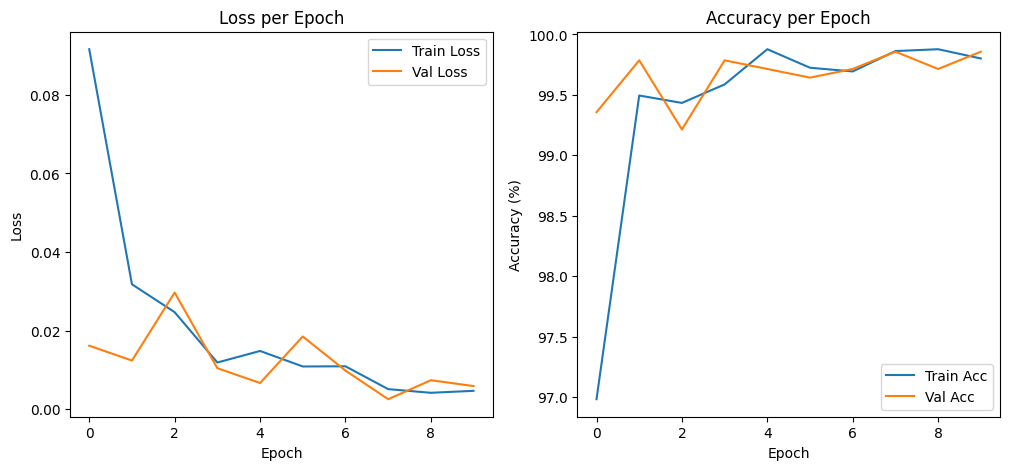

In [ ]:
"""
-----------------------------------------------------------------------------
This is the execution phase where the AI actively learns over 10 cycles (epochs). 

2.5.1. The Training Loop: For every batch, the model attempts to guess the gesture (Forward Pass), 
  calculates its error (Loss), and updates its internal weights to correct itself (Backward Pass).
2.5.2. The Validation Loop: After each training cycle, the model is tested on unseen data with 
  weight-updating strictly turned off (`torch.no_grad()`). This provides an objective measure 
  of its true accuracy.
2.5.3. Saving the Best Model: If the validation accuracy improves, that specific state is saved.

Outcome: By continuously updating parameters and validating against unseen data, the 
system guarantees that the absolute best, most accurate version of the model is safely 
saved.
-----------------------------------------------------------------------------
"""
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # if the device has GPU use it, else use CPU
model = model.to(device)

num_epochs = 10 # the num of times the model will go through the data

# used for comparision between each epoch
train_losses = []
train_accs = []
val_losses = []
val_accs = []

best_val_acc = 0.0

for epoch in range(num_epochs): 

    # training
    model.train() # put the model in training mode
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader: # repeat learning process until finish all images
        images, labels = images.to(device), labels.to(device) # put labels and images in the same device
        optimizer.zero_grad() # make old values = 0 every time
         # Forward Pass
        outputs = model(images) # model recaive image, pass it through layers, give possibility
        loss = criterion(outputs, labels) # calculate the diffrance between the prediction and the real value
         # Backward Pass
        loss.backward() 
        optimizer.step() # Adam updates the weights to reduce the loss

        # statistics
        running_loss += loss.item() 
        _, predicted = torch.max(outputs, 1) # take highest prediction
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # validation 
    model.eval() # put the model in validation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # to save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    # print result
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
"""
-----------------------------------------------------------------------------
Performance Analytics Graphing
Finally, the code generates visual line graphs tracking the Loss and Accuracy 
over the 10 epochs. 

Final Outcome: These graphs provide empirical proof that the model is highly 
stable, converges efficiently without overfitting, and is ready for hand gesture recognition in real-world applications.
-----------------------------------------------------------------------------
"""
# draw graphs
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss per Epoch")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy per Epoch")

plt.show()
